# Student Performance Prediction System - EDA

This notebook explores the synthetic student dataset and saves useful charts in the `outputs` folder.

## 1. Import Libraries

Pandas and NumPy help with data work. Matplotlib and Seaborn help us create charts.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_preprocessing import generate_synthetic_data, handle_missing_values, encode_categorical_columns

DATA_PATH = PROJECT_ROOT / 'data' / 'student_data.csv'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Dataset

If the CSV file does not exist, we generate 1000 synthetic student records.

In [2]:
if not DATA_PATH.exists():
    generate_synthetic_data(DATA_PATH, number_of_records=1000)

data = pd.read_csv(DATA_PATH)
data.head()

,student_id,attendance_percentage,assignment_score,midterm_marks,previous_grade,study_hours,participation,final_performance
0,1,81.66,71.11,60.77,C,5.80,Yes,Good
1,2,65.52,61.06,57.35,A,8.47,Yes,Good
2,3,87.01,65.78,74.94,C,2.14,Yes,Good
3,4,89.29,81.51,72.03,C,0.36,Yes,Average
4,5,54.59,72.04,45.52,D,2.13,No,Poor


## 3. Dataset Overview

In [3]:
print('Shape:', data.shape)
print('\nColumn Info:')
print(data.info())
print('\nSummary Statistics:')
data.describe()

Shape: (1000, 8)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             1000 non-null   int64  
 1   attendance_percentage  990 non-null    float64
 2   assignment_score       990 non-null    float64
 3   midterm_marks          990 non-null    float64
 4   previous_grade         990 non-null    str    
 5   study_hours            990 non-null    float64
 6   participation          990 non-null    str    
 7   final_performance      1000 non-null   str    
dtypes: float64(4), int64(1), str(3)
memory usage: 62.6 KB
None

Summary Statistics:


,student_id,attendance_percentage,assignment_score,midterm_marks,study_hours
count,1000.000000,990.000000,990.000000,990.000000,990.000000
mean,500.500000,77.532909,70.636606,68.294929,3.028242
std,288.819436,11.594446,14.906735,15.877507,1.922898
min,1.000000,35.000000,26.290000,18.980000,0.250000
25%,250.750000,69.657500,61.060000,57.405000,1.560000
50%,500.500000,78.075000,71.340000,68.515000,2.650000
75%,750.250000,85.085000,81.077500,79.300000,3.950000
max,1000.000000,100.000000,100.000000,100.000000,9.000000


## 4. Null Value Check

In [4]:
data.isnull().sum()

student_id                0
attendance_percentage    10
assignment_score         10
midterm_marks            10
previous_grade           10
study_hours              10
participation            10
final_performance         0
dtype: int64

## 5. Distribution Plots

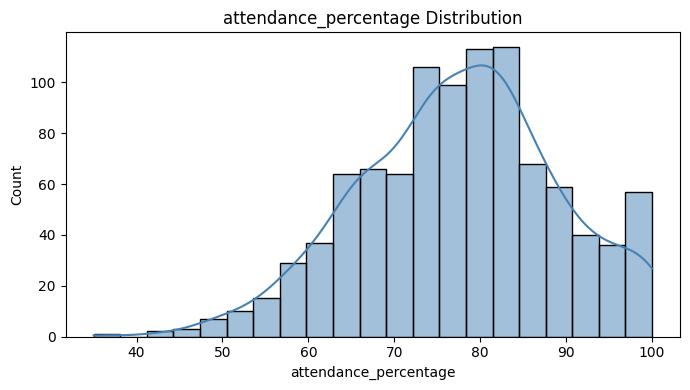

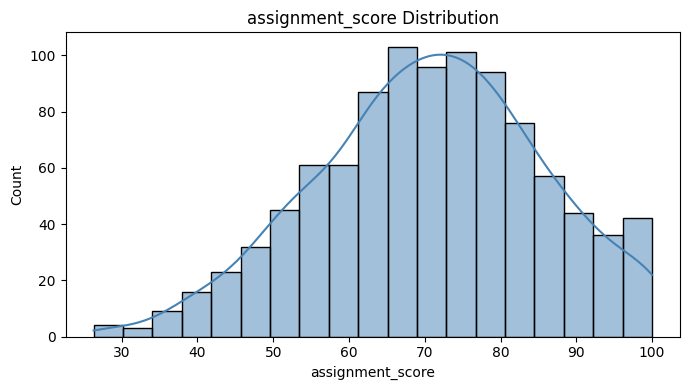

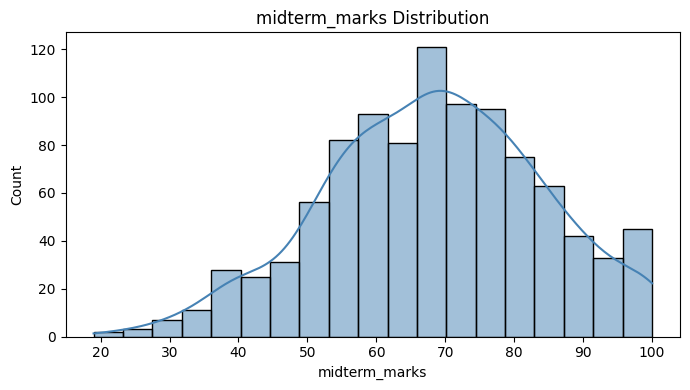

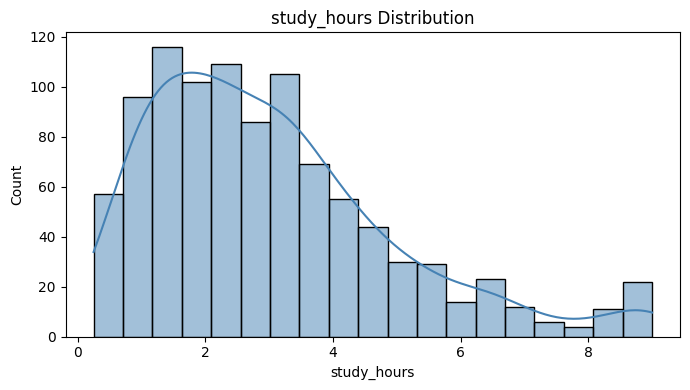

In [5]:
numeric_columns = ['attendance_percentage', 'assignment_score', 'midterm_marks', 'study_hours']

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(data[column], kde=True, color='steelblue')
    plt.title(f'{column} Distribution')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / f'{column}_distribution.png', dpi=150)
    plt.show()

## 6. Correlation Heatmap

Categorical columns are encoded first so correlation can be calculated.

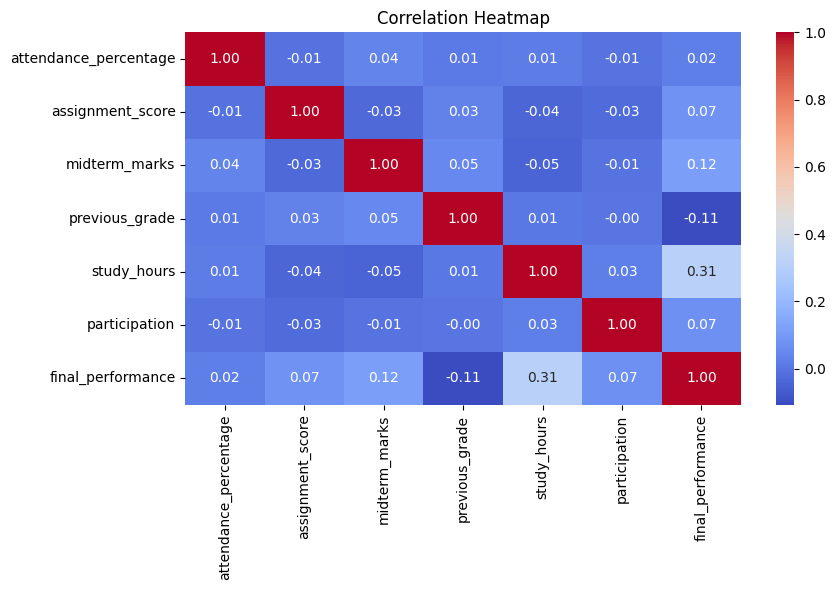

In [6]:
cleaned_data = handle_missing_values(data)
encoded_data, _ = encode_categorical_columns(cleaned_data)

plt.figure(figsize=(9, 6))
sns.heatmap(encoded_data.drop(columns=['student_id']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

## 7. Pair Plot

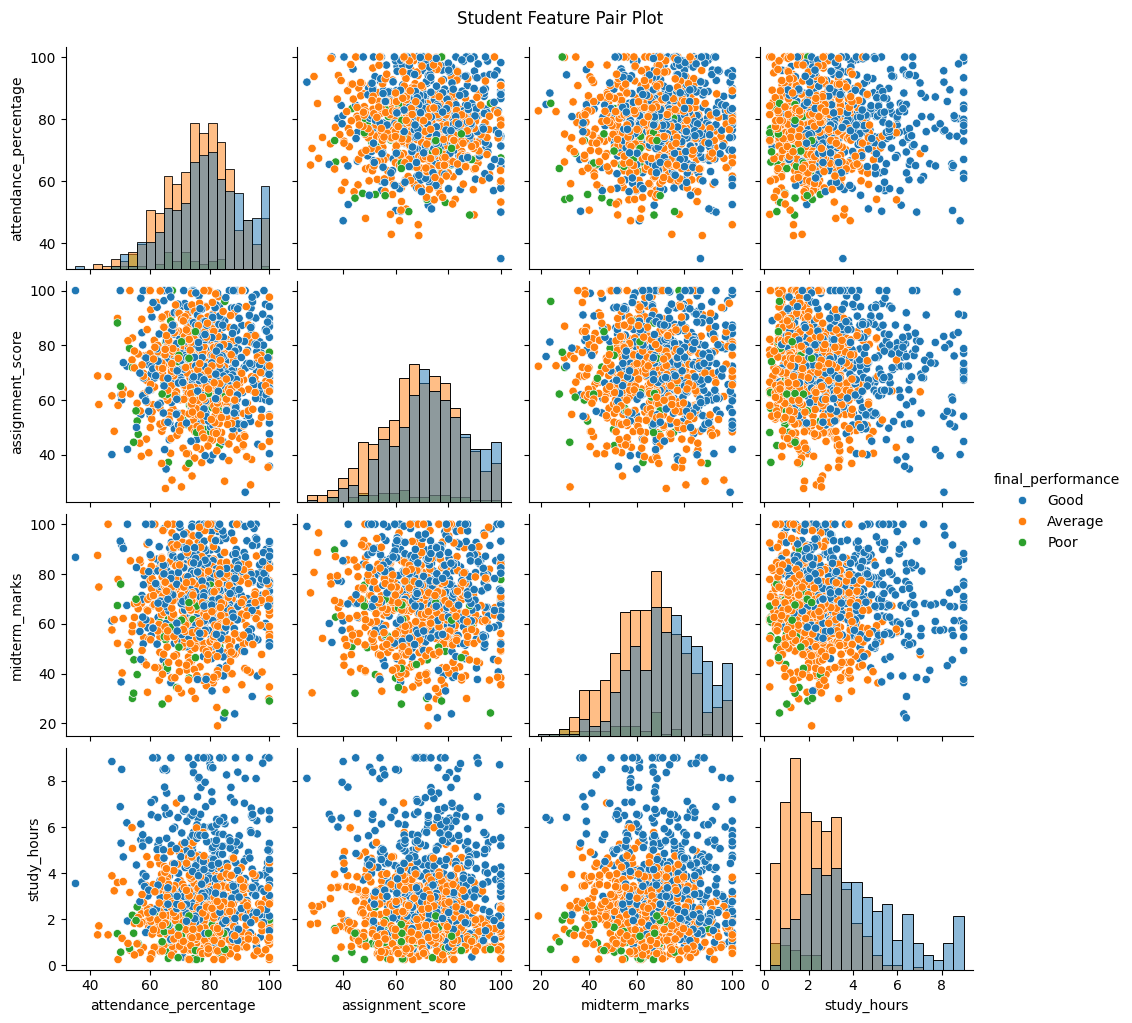

In [7]:
pair_plot = sns.pairplot(
    cleaned_data,
    vars=['attendance_percentage', 'assignment_score', 'midterm_marks', 'study_hours'],
    hue='final_performance',
    diag_kind='hist'
)
pair_plot.fig.suptitle('Student Feature Pair Plot', y=1.02)
pair_plot.savefig(OUTPUTS_DIR / 'pair_plot.png', dpi=150)
plt.show()

## 8. Class Distribution Chart

C:\Users\MAHESH YELEKAR\AppData\Local\Temp\ipykernel_1720\3375009066.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_data, x='final_performance', order=['Poor', 'Average', 'Good'], palette='Set2')


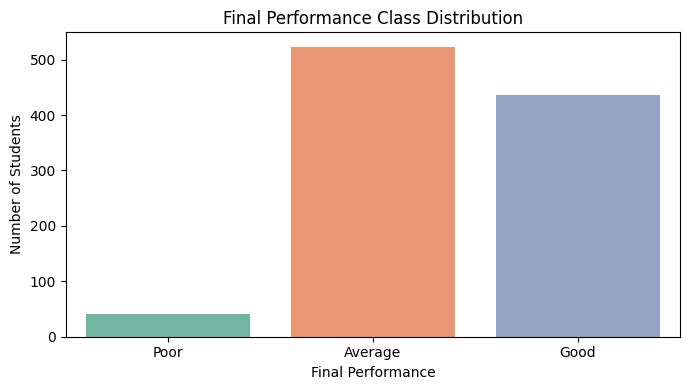

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=cleaned_data, x='final_performance', order=['Poor', 'Average', 'Good'], palette='Set2')
plt.title('Final Performance Class Distribution')
plt.xlabel('Final Performance')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'class_distribution.png', dpi=150)
plt.show()